In [1]:
# Install Kaggle library
!pip install kaggle --quiet

In [2]:
#Upload Kaggle.json file
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"siddhanshjainsid","key":"c44c0c16a27a1ced8fc11cd6556e81bc"}'}

In [3]:
!rm -rf ~/.kaggle # Remove existing directory
!mkdir ~/.kaggle # Recreate directory

In [4]:
!cp kaggle.json ~/.kaggle/

In [5]:
ls -ltr ~/.kaggle

total 4
-rw-r--r-- 1 root root 72 Apr 13 17:43 kaggle.json


In [6]:
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets list -s 'spotify_data clean.csv'

ref                                                              title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------  ----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
wardabilal/spotify-global-music-dataset-20092025                 Spotify Global Music Dataset (2009–2025)           1289021  2025-11-11 09:43:05.933000          26591        514                1  
alyahmedts13/spotify-songs-for-ml-and-analysis-over-8700-tracks  Spotify Songs for ML & Analysis (8700+ tracks)     1289021  2025-11-06 02:47:26.663000           1634         32                1  
ayushmittal1/spotify-clean                                       Spotify_Clean                                      1093111  2025-12-19 18:30:36.377000              3          1       0.29411766  
vinayak332/spot

In [8]:
!mkdir -p ../data/KaggleDataSetForSongsPopularity
!kaggle datasets download -d 'alyahmedts13/spotify-songs-for-ml-and-analysis-over-8700-tracks' -p ../data/KaggleDataSetForSongsPopularity

Dataset URL: https://www.kaggle.com/datasets/alyahmedts13/spotify-songs-for-ml-and-analysis-over-8700-tracks
License(s): CC0-1.0
100% 1.23M/1.23M [00:00<00:00, 143MB/s]



In [9]:
ls -ltr ../data/KaggleDataSetForSongsPopularity

total 1260
-rw-r--r-- 1 root root 1289021 Nov  6 02:47 spotify-songs-for-ml-and-analysis-over-8700-tracks.zip


In [10]:
!unzip -o ../data/KaggleDataSetForSongsPopularity/spotify-songs-for-ml-and-analysis-over-8700-tracks.zip -d ../data/KaggleDataSetForSongsPopularity

Archive:  ../data/KaggleDataSetForSongsPopularity/spotify-songs-for-ml-and-analysis-over-8700-tracks.zip
  inflating: ../data/KaggleDataSetForSongsPopularity/spotify_data clean.csv  
  inflating: ../data/KaggleDataSetForSongsPopularity/track_data_final.csv  


In [11]:
!chmod: 777 ../data/KaggleDataSetForSongsPopularity/spotify_data clean.csv

/bin/bash: line 1: chmod:: command not found


In [12]:
import pandas as pd
df = pd.read_csv('../data/KaggleDataSetForSongsPopularity/spotify_data clean.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nFirst few rows:")
df.head()

Dataset loaded successfully!
Shape: (8582, 15)

First few rows:


,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39


In [13]:
# ==============================================
# BASIC DATA OPERATIONS
# ==============================================

# 1. Display dataset information
print("="*50)
print("DATASET INFORMATION")
print("="*50)
df.info()

# 2. Display statistical summary
print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)
df.describe()

# 3. Check for missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# 4. Display column names and data types
print("\n" + "="*50)
print("COLUMN NAMES AND DATA TYPES")
print("="*50)
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8582 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8582 non-null   object 
 1   track_name          8582 non-null   object 
 2   track_number        8582 non-null   int64  
 3   track_popularity    8582 non-null   int64  
 4   explicit            8582 non-null   bool   
 5   artist_name         8579 non-null   object 
 6   artist_popularity   8582 non-null   int64  
 7   artist_followers    8582 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            8582 non-null   object 
 10  album_name          8582 non-null   object 
 11  album_release_date  8582 non-null   object 
 12  album_total_tracks  8582 non-null   int64  
 13  album_type          8582 non-null   object 
 14  track_duration_min  8582 non-null   float64
dtypes: bool(1), float64(1), int64(5), o

In [14]:
!ls -F ../data/KaggleDataSetForSongsPopularity/


'spotify_data clean.csv'				  track_data_final.csv
 spotify-songs-for-ml-and-analysis-over-8700-tracks.zip


In [15]:
import pandas as pd
import joblib
track_data_path = '../data/KaggleDataSetForSongsPopularity/track_data_final.csv'
df_track = pd.read_csv(track_data_path, delimiter=',', encoding='utf-8')

print("df_track has been defined and loaded.")
display(df_track.head())

df_track has been defined and loaded.


,track_id,track_name,track_number,track_popularity,track_duration_ms,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type
0,6pymOcrCnMuCWdgGVTvUgP,3,57,61,213173,False,Britney Spears,80.0,17755451.0,['pop'],325wcm5wMnlfjmKZ8PXIIn,The Singles Collection,2009-11-09,58,compilation
1,2lWc1iJlz2NVcStV5fbtPG,Clouds,1,67,158760,False,BUNT.,69.0,293734.0,['stutter house'],2ArRQNLxf9t0O0gvmG5Vsj,Clouds,2023-01-13,1,single
2,1msEuwSBneBKpVCZQcFTsU,Forever & Always (Taylor’s Version),11,63,225328,False,Taylor Swift,100.0,145396321.0,[],4hDok0OAJd57SGIT8xuWJH,Fearless (Taylor's Version),2021-04-09,26,album
3,7bcy34fBT2ap1L4bfPsl9q,I Didn't Change My Number,2,72,158463,True,Billie Eilish,90.0,118692183.0,[],0JGOiO34nwfUdDrD612dOp,Happier Than Ever,2021-07-30,16,album
4,0GLfodYacy3BJE7AI3A8en,Man Down,7,57,267013,False,Rihanna,90.0,68997177.0,[],5QG3tjE5L9F6O2vCAPph38,Loud,2010-01-01,13,album


In [16]:
# ==============================================
# DATA EXPLORATION & ANALYSIS for df_track
# ==============================================

import numpy as np

# 5. Display unique values for categorical columns
print("\n" + "="*50)
print("UNIQUE VALUES IN KEY COLUMNS (df_track)")
print("="*50)
if 'explicit' in df_track.columns:
    print(f"\nExplicit: {df_track['explicit'].unique()}")
    print(f"Explicit count: {df_track['explicit'].value_counts()}")

# 6. Top 10 most popular tracks
if 'track_popularity' in df_track.columns:
    print("\n" + "="*50)
    print("TOP 10 MOST POPULAR TRACKS (df_track)")
    print("="*50)
    top_tracks_track = df_track.nlargest(10, 'track_popularity')[['track_name', 'artist_name', 'track_popularity']]
    print(top_tracks_track)

# 7. Top 10 most popular artists
if 'artist_popularity' in df_track.columns:
    print("\n" + "="*50)
    print("TOP 10 MOST POPULAR ARTISTS (df_track)")
    print("="*50)
    # Drop duplicates for artists to count unique artists
    top_artists_track = df_track.nlargest(10, 'artist_popularity')[['artist_name', 'artist_popularity']].drop_duplicates(subset=['artist_name'])
    print(top_artists_track.head(10))

# 8. Correlation analysis for numerical columns
print("\n" + "="*50)
print("CORRELATION MATRIX (Numerical Columns - df_track)")
print("="*50)
numerical_cols_track = df_track.select_dtypes(include=[np.number]).columns
correlation_matrix_track = df_track[numerical_cols_track].corr()
print(correlation_matrix_track)



UNIQUE VALUES IN KEY COLUMNS (df_track)

Explicit: [False  True]
Explicit count: explicit
False    6586
True     2192
Name: count, dtype: int64

TOP 10 MOST POPULAR TRACKS (df_track)
               track_name    artist_name  track_popularity
7093  The Fate of Ophelia   Taylor Swift               100
4373               Golden        HUNTR/X                99
5497              Opalite   Taylor Swift                97
3636           Man I Need    Olivia Dean                95
6451     Elizabeth Taylor   Taylor Swift                95
1391   BIRDS OF A FEATHER  Billie Eilish                94
3126             Soda Pop      Saja Boys                94
8659        Father Figure   Taylor Swift                94
1859        How It’s Done        HUNTR/X                93
2145            Your Idol      Saja Boys                93

TOP 10 MOST POPULAR ARTISTS (df_track)
    artist_name  artist_popularity
2  Taylor Swift              100.0

CORRELATION MATRIX (Numerical Columns - df_track)
      

In [17]:
# ==============================================
# BASIC DATA OPERATIONS for df_track
# ==============================================

# 1. Display dataset information
print("\n" + "="*50)
print("DATASET INFORMATION (df_track)")
print("="*50)
df_track.info()

# 2. Display statistical summary
print("\n" + "="*50)
print("STATISTICAL SUMMARY (df_track)")
print("="*50)
print(df_track.describe())

# 3. Check for missing values
print("\n" + "="*50)
print("MISSING VALUES (df_track)")
print("="*50)
missing_values_track = df_track.isnull().sum()
print(missing_values_track[missing_values_track > 0])
print(f"\nTotal missing values in df_track: {df_track.isnull().sum().sum()}")

# 4. Display column names and data types
print("\n" + "="*50)
print("COLUMN NAMES AND DATA TYPES (df_track)")
print("="*50)
for col in df_track.columns:
    print(f"{col}: {df_track[col].dtype}")


DATASET INFORMATION (df_track)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8778 entries, 0 to 8777
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            8778 non-null   object 
 1   track_name          8776 non-null   object 
 2   track_number        8778 non-null   int64  
 3   track_popularity    8778 non-null   int64  
 4   track_duration_ms   8778 non-null   int64  
 5   explicit            8778 non-null   bool   
 6   artist_name         8774 non-null   object 
 7   artist_popularity   8774 non-null   float64
 8   artist_followers    8774 non-null   float64
 9   artist_genres       8774 non-null   object 
 10  album_id            8778 non-null   object 
 11  album_name          8776 non-null   object 
 12  album_release_date  8778 non-null   object 
 13  album_total_tracks  8778 non-null   int64  
 14  album_type          8778 non-null   object 
dtypes: bool(1), float64(2),

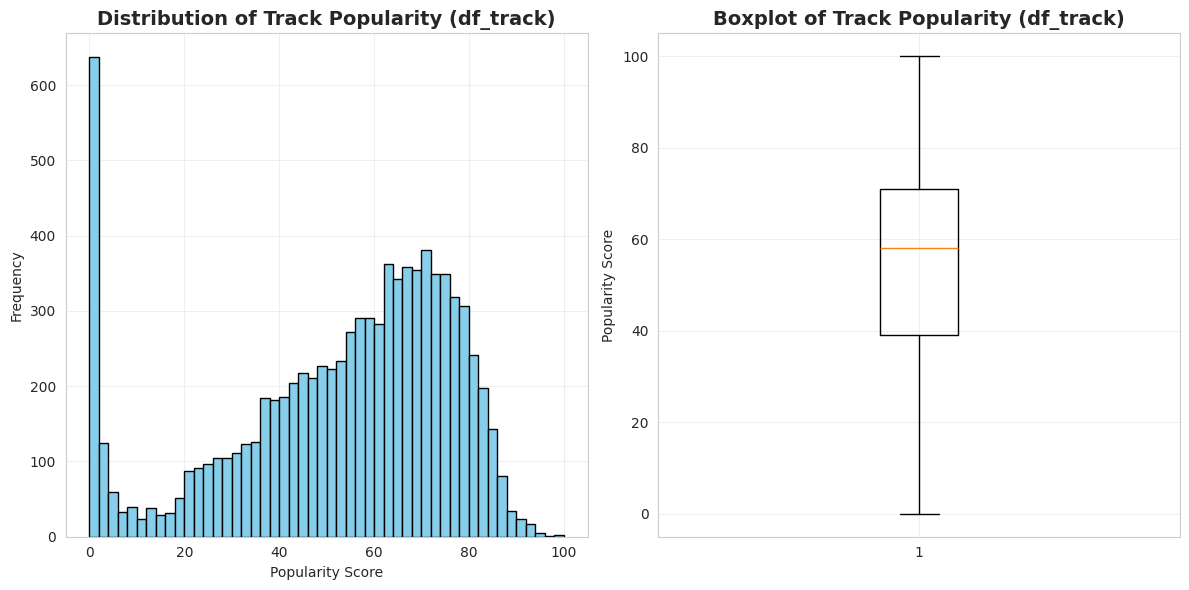

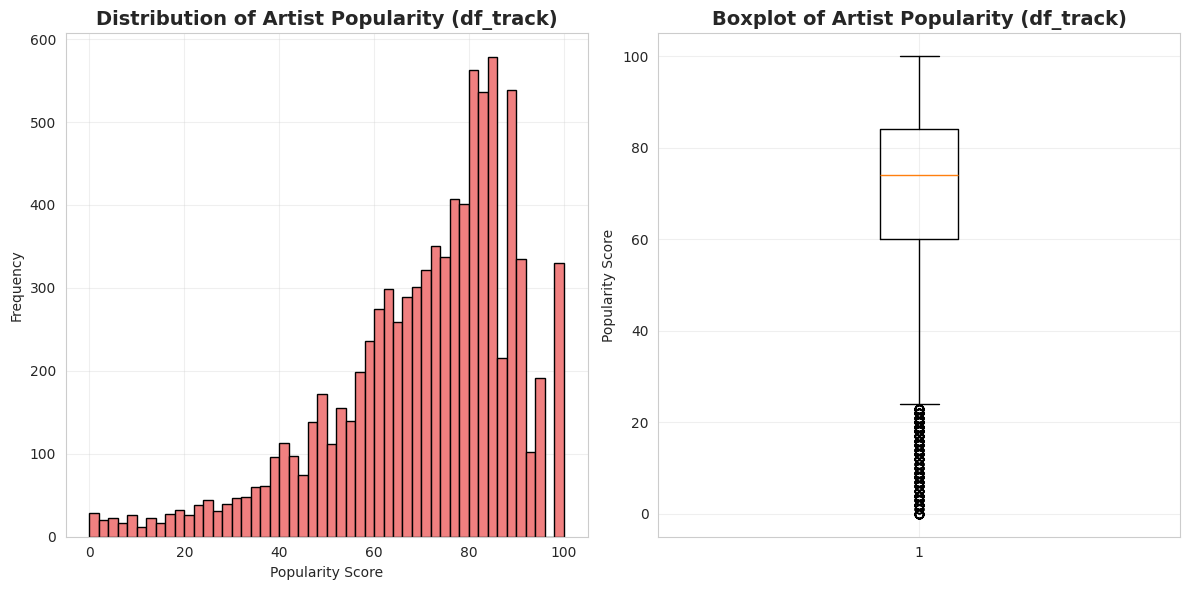

In [18]:
# ==============================================
# DATA VISUALIZATIONS for df_track
# ==============================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Distribution of Track Popularity
if 'track_popularity' in df_track.columns:
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.hist(df_track['track_popularity'], bins=50, color='skyblue', edgecolor='black')
    plt.title('Distribution of Track Popularity (df_track)', fontsize=14, fontweight='bold')
    plt.xlabel('Popularity Score')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.boxplot(df_track['track_popularity'], vert=True)
    plt.title('Boxplot of Track Popularity (df_track)', fontsize=14, fontweight='bold')
    plt.ylabel('Popularity Score')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 2. Distribution of Artist Popularity
if 'artist_popularity' in df_track.columns:
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.hist(df_track['artist_popularity'].dropna(), bins=50, color='lightcoral', edgecolor='black') # dropna for plotting
    plt.title('Distribution of Artist Popularity (df_track)', fontsize=14, fontweight='bold')
    plt.xlabel('Popularity Score')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.boxplot(df_track['artist_popularity'].dropna(), vert=True) # dropna for plotting
    plt.title('Boxplot of Artist Popularity (df_track)', fontsize=14, fontweight='bold')
    plt.ylabel('Popularity Score')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


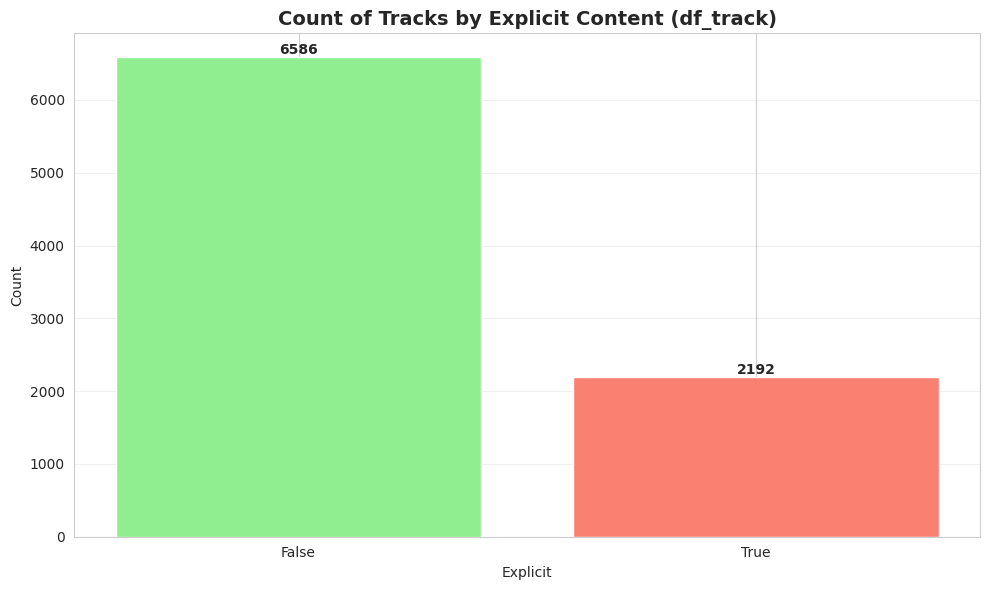

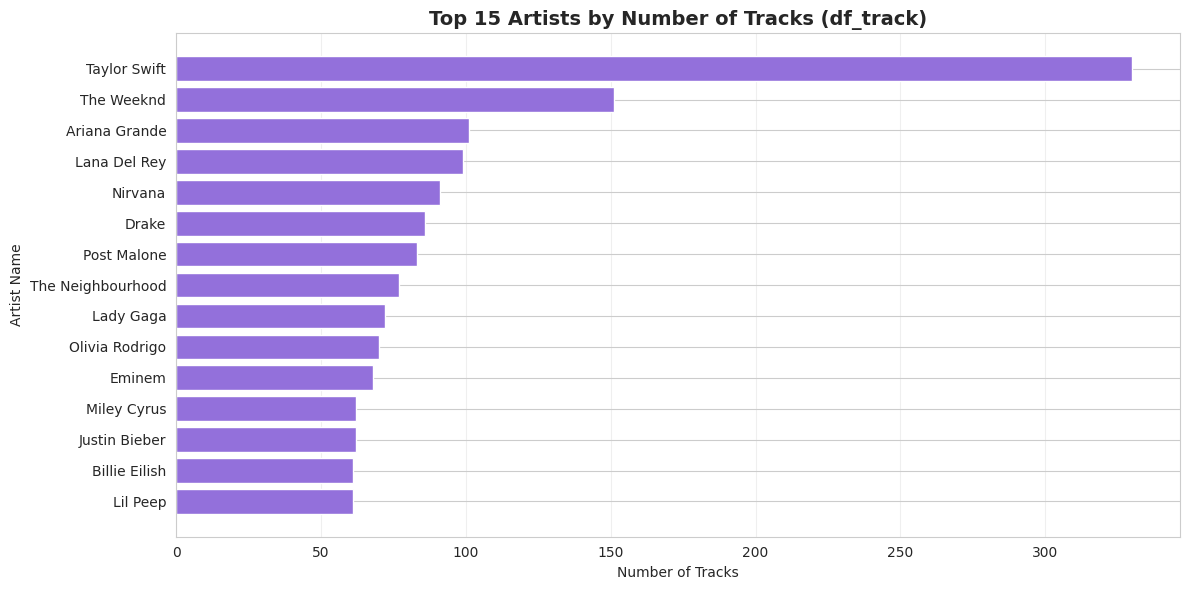

In [19]:
# 3. Count plot for Explicit Content
if 'explicit' in df_track.columns:
    plt.figure(figsize=(10, 6))
    explicit_counts_track = df_track['explicit'].value_counts()
    plt.bar(explicit_counts_track.index.astype(str), explicit_counts_track.values, color=['lightgreen', 'salmon'])
    plt.title('Count of Tracks by Explicit Content (df_track)', fontsize=14, fontweight='bold')
    plt.xlabel('Explicit')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(explicit_counts_track.values):
        plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

# 4. Top 15 Artists by Track Count
if 'artist_name' in df_track.columns:
    plt.figure(figsize=(12, 6))
    top_artists_track_count = df_track['artist_name'].value_counts().head(15)
    plt.barh(range(len(top_artists_track_count)), top_artists_track_count.values, color='mediumpurple')
    plt.yticks(range(len(top_artists_track_count)), top_artists_track_count.index)
    plt.title('Top 15 Artists by Number of Tracks (df_track)', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Tracks')
    plt.ylabel('Artist Name')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()


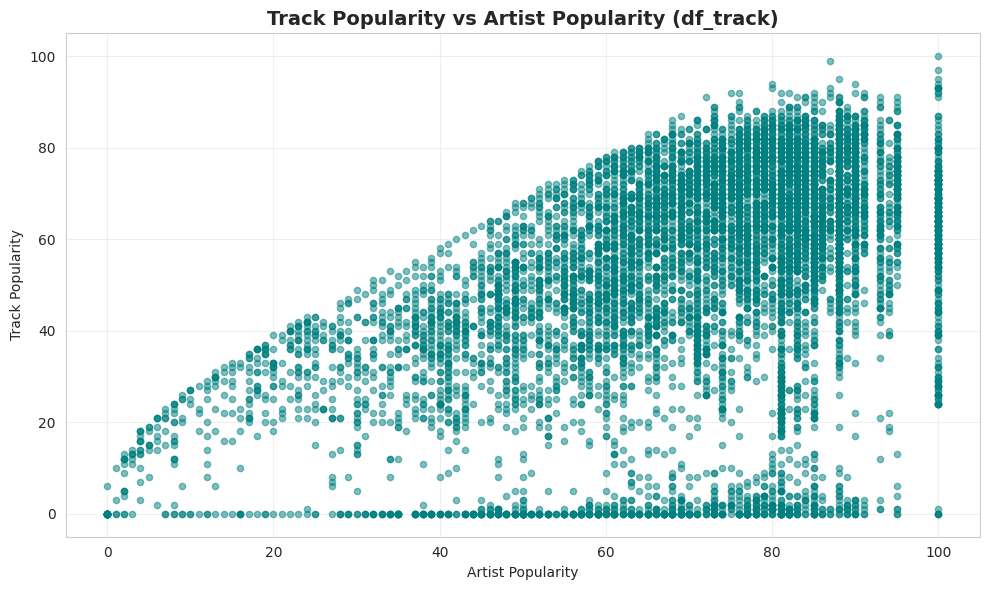

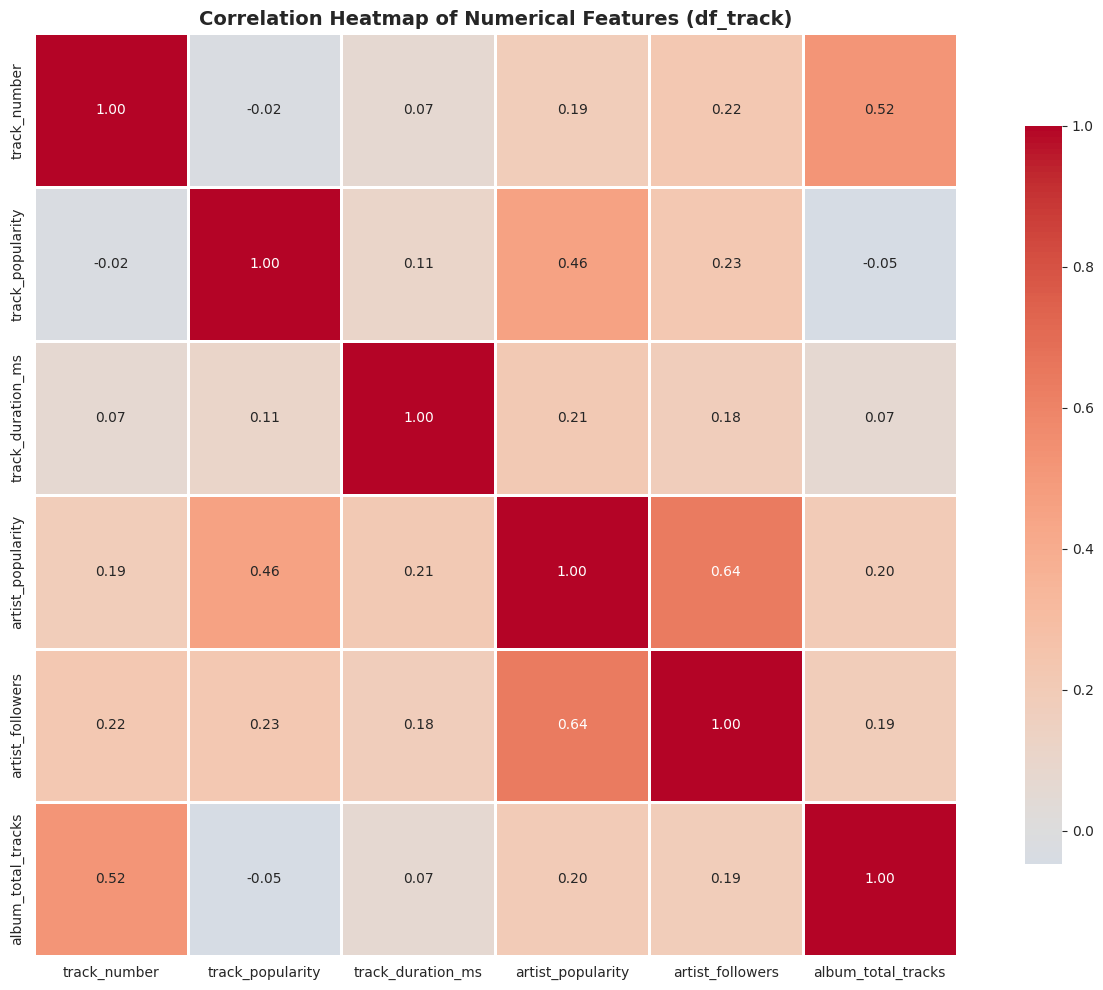

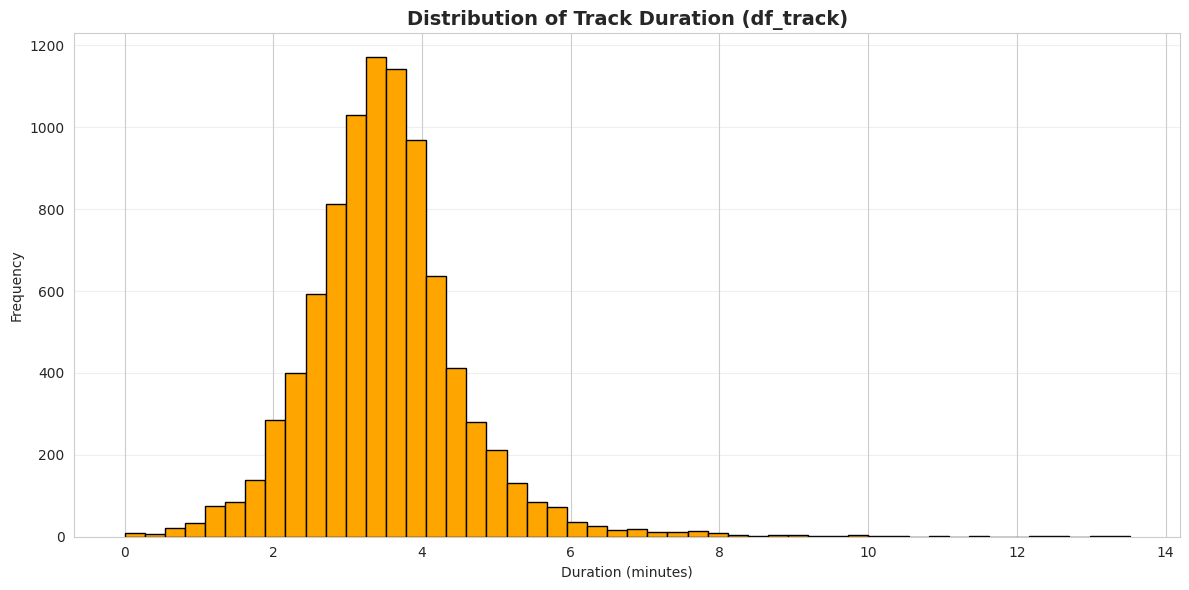

In [20]:
# 5. Scatter plot: Track Popularity vs Artist Popularity
if 'track_popularity' in df_track.columns and 'artist_popularity' in df_track.columns:
    plt.figure(figsize=(10, 6))
    plt.scatter(df_track['artist_popularity'], df_track['track_popularity'], alpha=0.5, c='teal', s=20)
    plt.title('Track Popularity vs Artist Popularity (df_track)', fontsize=14, fontweight='bold')
    plt.xlabel('Artist Popularity')
    plt.ylabel('Track Popularity')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 6. Correlation Heatmap
if len(df_track.select_dtypes(include=[np.number]).columns) > 1:
    plt.figure(figsize=(14, 10))
    correlation_matrix_track = df_track.select_dtypes(include=[np.number]).corr()
    sns.heatmap(correlation_matrix_track, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Heatmap of Numerical Features (df_track)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 7. Track Duration Distribution
if 'track_duration_ms' in df_track.columns:
    plt.figure(figsize=(12, 6))
    # Convert milliseconds to minutes
    track_duration_min = df_track['track_duration_ms'] / 60000
    plt.hist(track_duration_min, bins=50, color='orange', edgecolor='black')
    plt.title('Distribution of Track Duration (df_track)', fontsize=14, fontweight='bold')
    plt.xlabel('Duration (minutes)')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


In [21]:
# Import essential libraries and suppress warnings
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd


In [22]:

import matplotlib
matplotlib.use('Agg')  # Use Anti-Grain Geometry to prevent GUI-based rendering issues
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
# Set plot style for consistency
sns.set(style='whitegrid', palette='muted', color_codes=True)

# For reproducibility
RANDOM_STATE = 42

In [23]:
# Load the datasets
track_data_path = '../data/KaggleDataSetForSongsPopularity/track_data_final.csv'
spotify_clean_path = '../data/KaggleDataSetForSongsPopularity/spotify_data clean.csv'

df_track = pd.read_csv(track_data_path, delimiter=',', encoding='utf-8')
df_spotify = pd.read_csv(spotify_clean_path, delimiter=',', encoding='utf-8')

# Display basic info
print('Track Data Shape:', df_track.shape)
print('Spotify Clean Data Shape:', df_spotify.shape)

Track Data Shape: (8778, 15)
Spotify Clean Data Shape: (8582, 15)


In [24]:
# Convert album_release_date to datetime in both dataframes
for df in [df_track, df_spotify]:
    if 'album_release_date' in df.columns:
        # Infer format: sometimes only year is provided, sometimes a complete date
        try:
            df['album_release_date'] = pd.to_datetime(df['album_release_date'], errors='coerce')
        except Exception as e:
            print('Error in converting album_release_date:', e)

# Check for missing values
print('Missing values in track_data_final.csv:')
print(df_track.isnull().sum())

print('\nMissing values in spotify_data clean.csv:')
print(df_spotify.isnull().sum())

# Remove duplicate rows if any
initial_shape = df_track.shape
df_track.drop_duplicates(inplace=True)
print('\nRemoved {} duplicates from track_data_final.csv.'.format(initial_shape[0] - df_track.shape[0]))

Missing values in track_data_final.csv:
track_id                0
track_name              2
track_number            0
track_popularity        0
track_duration_ms       0
explicit                0
artist_name             4
artist_popularity       4
artist_followers        4
artist_genres           4
album_id                0
album_name              2
album_release_date    201
album_total_tracks      0
album_type              0
dtype: int64

Missing values in spotify_data clean.csv:
track_id                 0
track_name               0
track_number             0
track_popularity         0
explicit                 0
artist_name              3
artist_popularity        0
artist_followers         0
artist_genres         3361
album_id                 0
album_name               0
album_release_date       0
album_total_tracks       0
album_type               0
track_duration_min       0
dtype: int64

Removed 0 duplicates from track_data_final.csv.


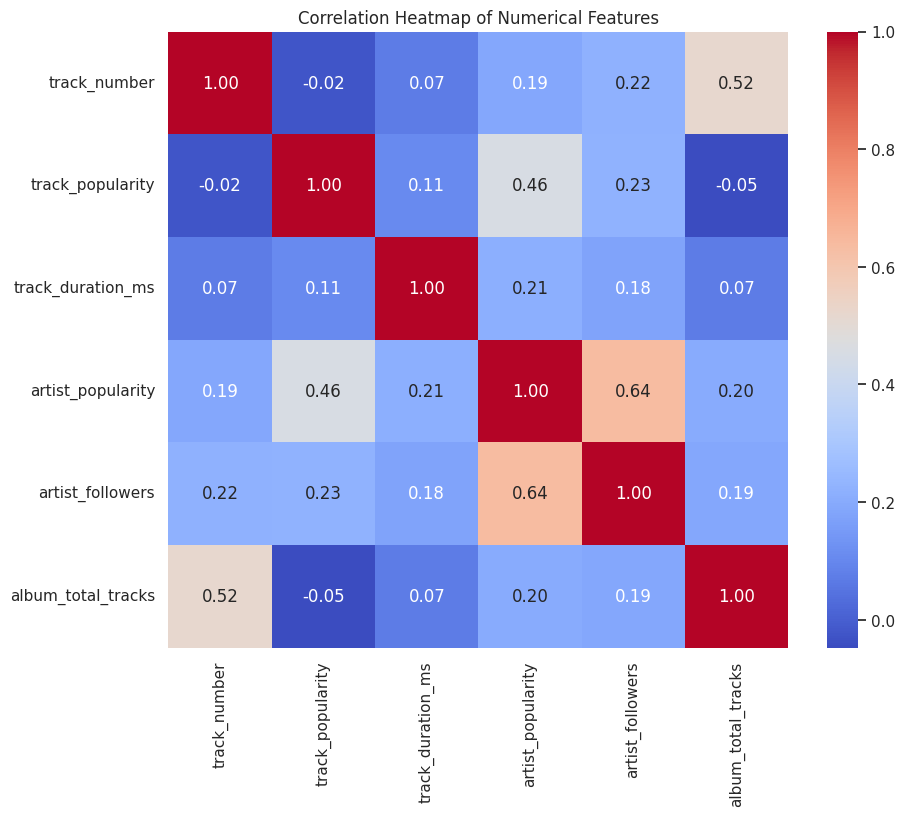

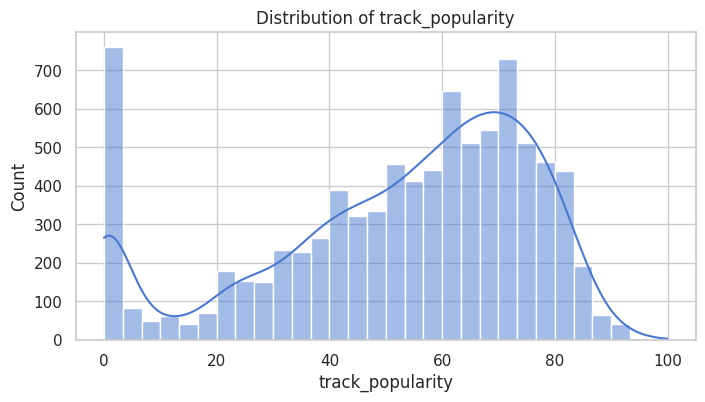

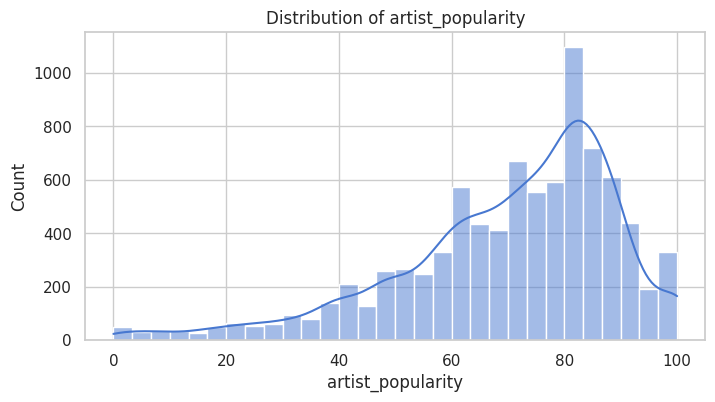

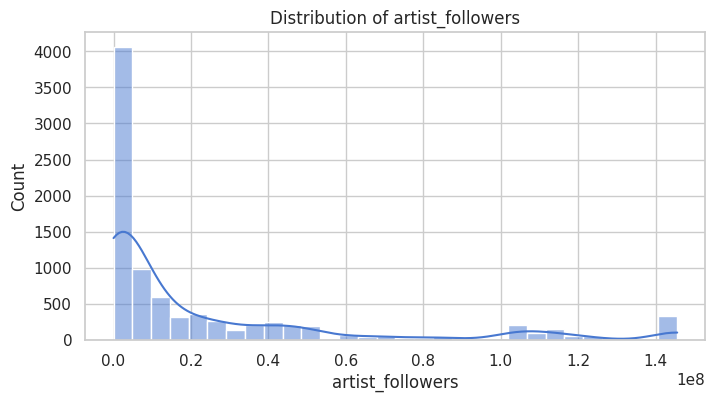

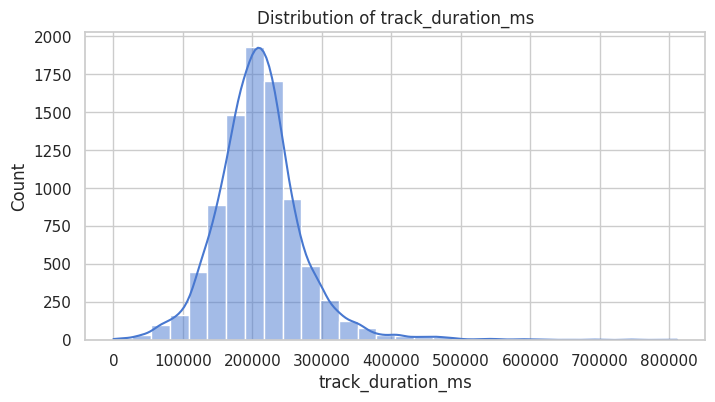

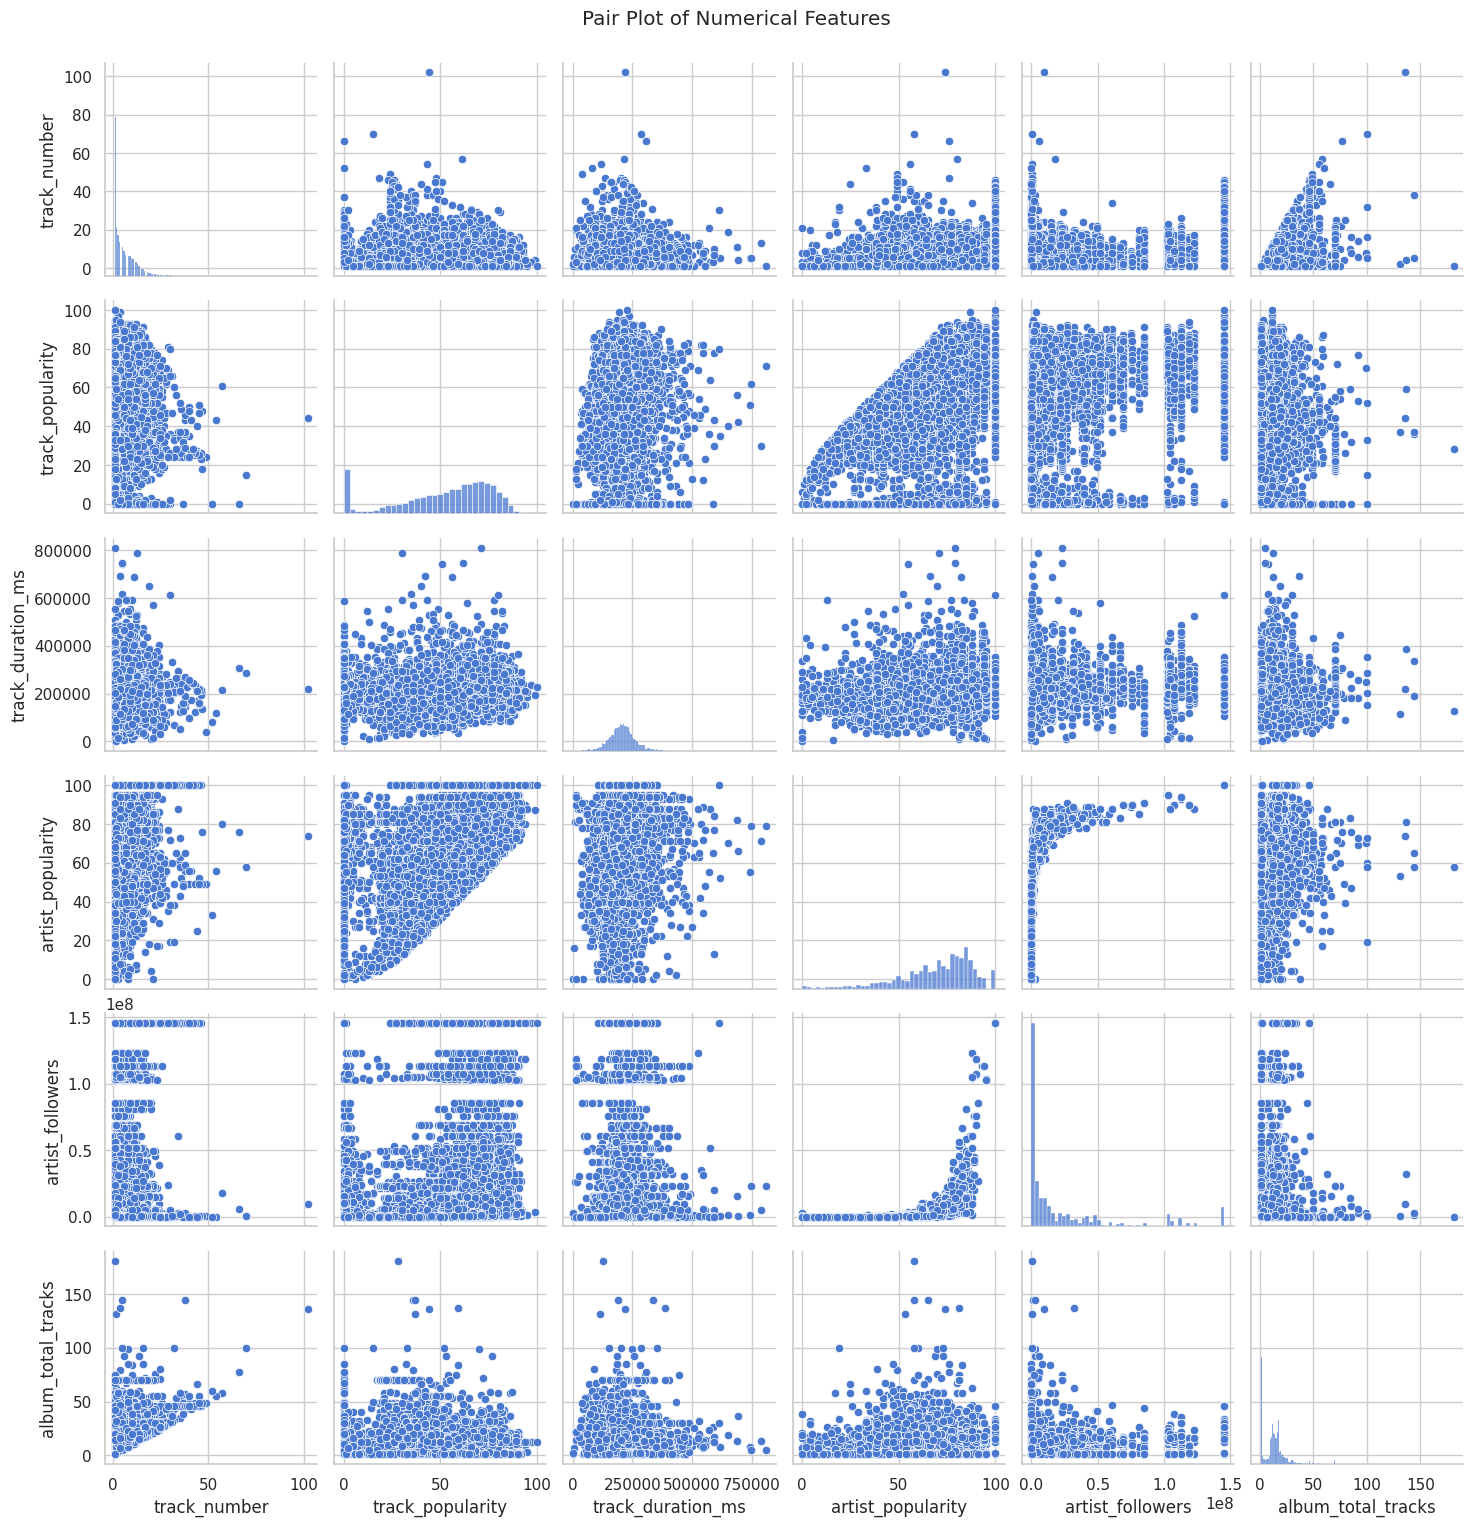

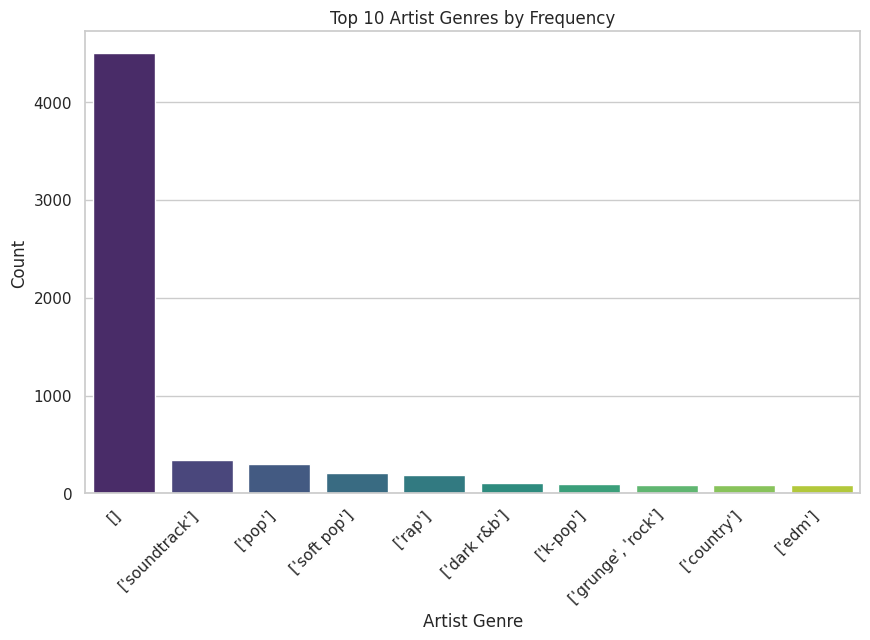

In [25]:
# Select the numeric portion for correlation heatmap
numeric_df = df_track.select_dtypes(include=[np.number])

# Plot correlation heatmap (only if there are at least 4 numeric columns)
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numerical Features')
    plt.show()
else:
    print('Not enough numeric features for a correlation heatmap.')

# Histograms for a few key numeric columns
numeric_cols = ['track_popularity', 'artist_popularity', 'artist_followers', 'track_duration_ms']
for col in numeric_cols:
    if col in df_track.columns:
        plt.figure(figsize=(8, 4))
        sns.histplot(df_track[col].dropna(), kde=True, bins=30)
        plt.title('Distribution of ' + col)
        plt.show()

# Pair plot for numeric features (if available)
if numeric_df.shape[1] >= 2:
    sns.pairplot(numeric_df.dropna())
    plt.suptitle('Pair Plot of Numerical Features', y=1.02)
    plt.show()

# Count plot for a categorical feature (artist_genres)
# Note: Since artist_genres might have many unique values, we display the top 10
top_genres = df_track['artist_genres'].value_counts().nlargest(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.index, y=top_genres.values, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Artist Genres by Frequency')
plt.xlabel('Artist Genre')
plt.ylabel('Count')
plt.show()

Random Forest Regressor Performance:
R² Score: 0.22337646712504644
Mean Squared Error: 453.0353842229673


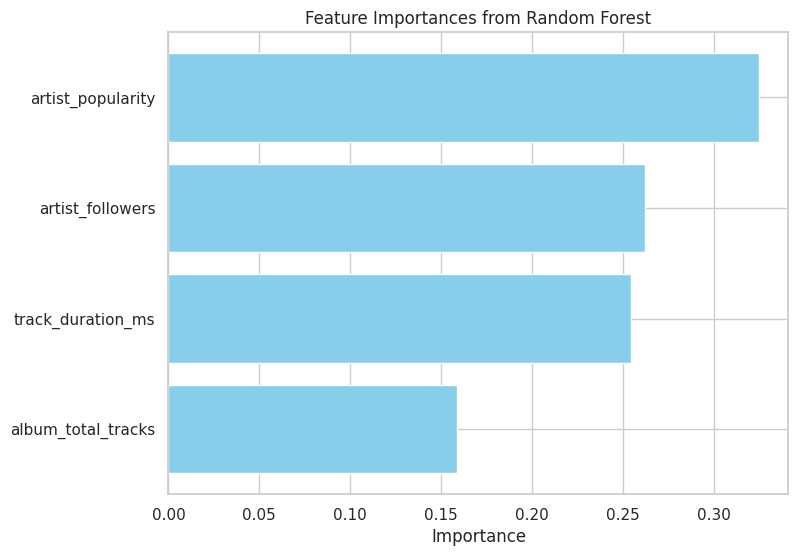

In [26]:
# Prepare the dataset for modeling
model_df = df_track.copy()

# Define the feature columns and target variable
features = ['track_duration_ms', 'album_total_tracks', 'artist_popularity', 'artist_followers']
target = 'track_popularity'

# Check if all features exist in the dataframe
for feature in features:
    if feature not in model_df.columns:
        raise ValueError(f"Missing required feature: {feature}")

# Drop rows with missing values in the selected columns
model_df = model_df[features + [target]].dropna()

# Split the data into train and test sets
X = model_df[features]
y = model_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE)

# Initialize and train the Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print('Random Forest Regressor Performance:')
print('R² Score:', r2)
print('Mean Squared Error:', mse)
# Feature importance plot
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.show()

In [27]:
import pickle

# Save the trained model using pickle
with open('random_forest_model.pickle', 'wb') as file:
    pickle.dump(rf_model, file)
print("Model exported successfully as 'random_forest_model.pickle'")

Model exported successfully as 'random_forest_model.pickle'


In [28]:
import pickle

# Load the exported model using pickle
with open('random_forest_model.pickle', 'rb') as file:
    loaded_rf_model_pickle = pickle.load(file)

print("Model loaded successfully from 'random_forest_model.pickle'!")

Model loaded successfully from 'random_forest_model.pickle'!


In [29]:
with open('random_forest_model.pickle', 'wb') as file:
    pickle.dump(rf_model, file)